In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score


#loading datasets

df_offense = pd.read_csv("/Users/philtchoko/Desktop/DATS4001/all_leagues_offense.csv")
df_midfield = pd.read_csv("/Users/philtchoko/Desktop/DATS4001/all_leagues_midfield.csv")
df_defense = pd.read_csv("/Users/philtchoko/Desktop/DATS4001/all_leagues_defense.csv")


def feature_selection_via_correlation(df, target_column="Value", threshold=0.2):
    # selecting numeric columns
    num_df = df.select_dtypes(include=np.number)

    # calculating correlation matrix
    corr_matrix = num_df.corr()

    # focusing on target column
    target_corr = corr_matrix[target_column].drop(labels=[target_column])

    # Select features with correlation above the threshold
    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()

    print(f"\n📈 Features Selected (|correlation| > {threshold}):")
    print(selected_features)

    return selected_features

#print(df_offense.head(), df_midfield.head(), df_defense.head())

feature_selection_via_correlation(df_offense, "Value", 0.3)
feature_selection_via_correlation(df_midfield, "Value", 0.3)
feature_selection_via_correlation(df_defense, "Value", 0.25)


📈 Features Selected (|correlation| > 0.3):
['Gls_Per_Minutes', 'PK', 'Gls', 'Ast', 'G+A', 'xG_Expected.x', 'xAG_Expected', 'Sh_Standard']

📈 Features Selected (|correlation| > 0.3):
['Ast', 'xAG', 'KP', 'PrgP', 'PrgC_Carries']

📈 Features Selected (|correlation| > 0.25):
['Unnamed: 0', 'Att 3rd_Tackles', 'Blocks_Blocks', 'Pass_Blocks']


['Unnamed: 0', 'Att 3rd_Tackles', 'Blocks_Blocks', 'Pass_Blocks']

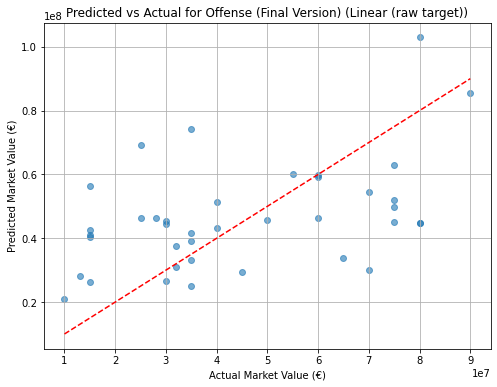

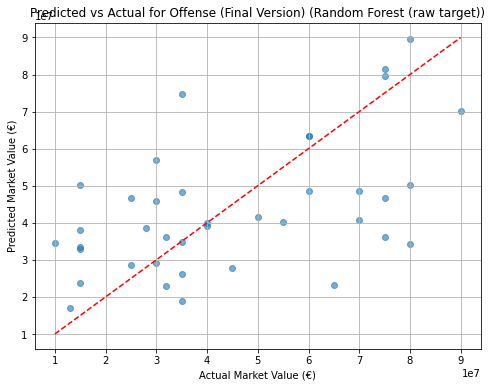

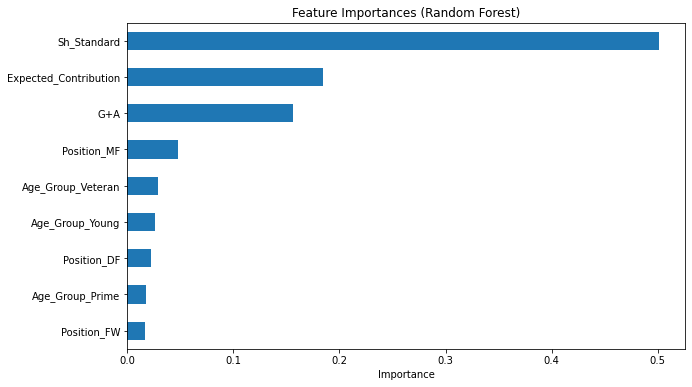


📊 Results for Offense (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.154573 2.141236e+07
       Linear (log target) -0.081874 2.422227e+07
Random Forest (raw target)  0.218450 2.058757e+07
Random Forest (log target)  0.067701 2.248559e+07


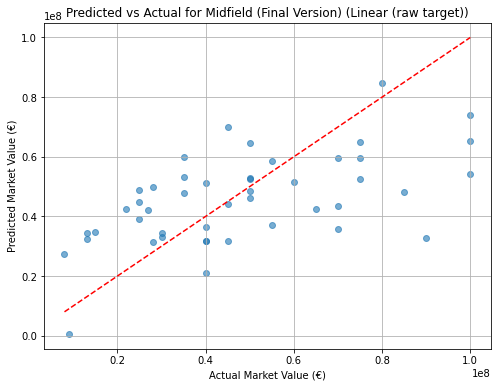

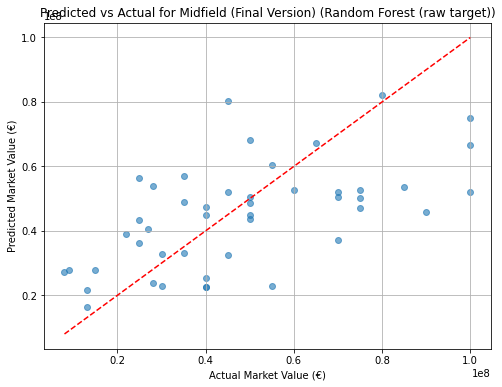

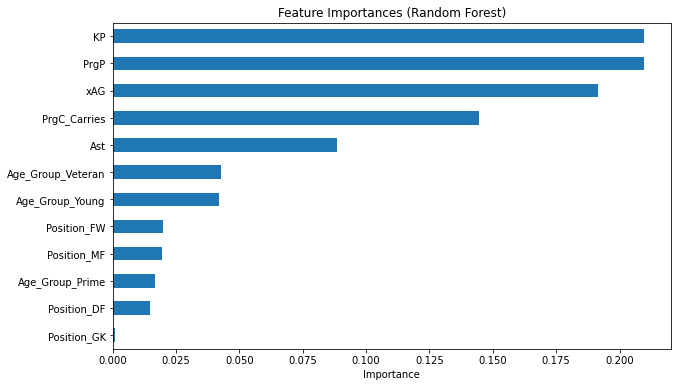


📊 Results for Midfield (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.318682 2.040977e+07
       Linear (log target)  0.161976 2.263556e+07
Random Forest (raw target)  0.329149 2.025239e+07
Random Forest (log target)  0.132249 2.303354e+07


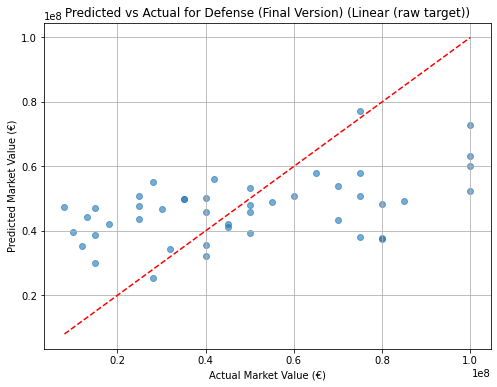

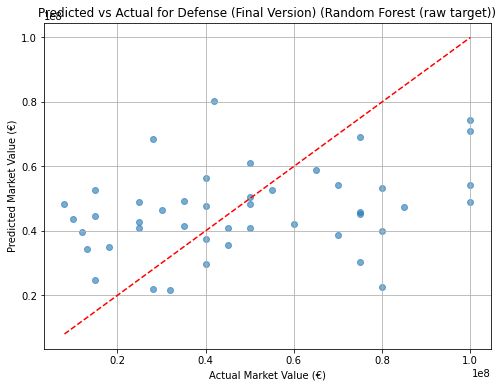

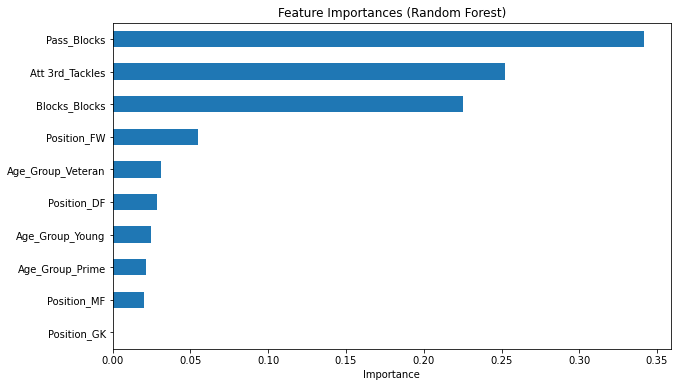


📊 Results for Defense (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.236338 2.364282e+07
       Linear (log target)  0.152417 2.490806e+07
Random Forest (raw target)  0.062420 2.619708e+07
Random Forest (log target) -0.075741 2.806097e+07


In [ ]:



# Helper Functions

def bin_age(age):
    if pd.isnull(age):
        return np.nan
    elif age <= 22:
        return "Young"
    elif 23 <= age <= 29:
        return "Prime"
    else:
        return "Veteran"

def clean_columns(df):
    """Fix messy column names."""
    rename_map = {}
    if "Value.x" in df.columns:
        rename_map["Value.x"] = "Value"
    if "Position.x" in df.columns:
        rename_map["Position.x"] = "Position"
    if "Age.x.x" in df.columns:
        rename_map["Age.x.x"] = "Age"
    if "Age.x" in df.columns and "Age" not in df.columns:
        rename_map["Age.x"] = "Age"

    df = df.rename(columns=rename_map)
    return df

import matplotlib.pyplot as plt
import numpy as np

def plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, model_name):
    # Predict
    y_pred = pipeline.predict(X_test)

    # If model was trained on log target, undo exp() transform
    if model_name.endswith("(log target)"):
        y_test = np.exp(y_test)
        y_pred = np.exp(y_pred)

    # Scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
    plt.xlabel("Actual Market Value (€)")
    plt.ylabel("Predicted Market Value (€)")
    plt.title(f"Predicted vs Actual for {dataset_name} ({model_name})")
    plt.grid(True)
    plt.show()


# best features from corr tests
selected_feature_list = {
    "Offense (Final Version)": ['G+A', 'Expected_Contribution', 'Sh_Standard'],
    "Midfield (Final Version)": ['Ast', 'xAG', 'KP', 'PrgP', 'PrgC_Carries'],
    "Defense (Final Version)": ['Att 3rd_Tackles', 'Blocks_Blocks', 'Pass_Blocks']
}

def run_modeling_pipeline(df, dataset_name, target_column="Value"):
    # Clean and standardize
    df = clean_columns(df)
    df = df.drop(columns=[col for col in ["Unnamed: 0", "Squad", "Pos", "Player", "Team",
                                          "PlayerURL", "Season", "Comp", "Nation",
                                          "Season.x", "Comp.x", "Nation.x", "Team.x", "Player.x", "Apps.x"]
                if col in df.columns], errors='ignore')

    # Drop missing target values
    df = df.dropna(subset=[target_column])

    # Winsorize extreme values
    winsorization_cap = 100_000_000
    df[target_column] = np.where(df[target_column] > winsorization_cap, winsorization_cap, df[target_column])

    # Create Expected Contribution (only for Offense dataset)
    if dataset_name == "Offense (Final Version)":
        if {"xG_Expected.x", "xAG_Expected"}.issubset(df.columns):
            df["Expected_Contribution"] = df["xG_Expected.x"] + df["xAG_Expected"]

    # Add Age Group
    df["Age_Group"] = df["Age"].apply(bin_age)

    # Log-transform the target
    df["LogValue"] = np.log(df[target_column])

    # Drop rows with missing features
    df_cleaned = df.dropna()

    # Select only the best features + Position + Age_Group
    selected_features = selected_feature_list[dataset_name]
    keep_features = selected_features + ["Position", "Age_Group"]

    features = df_cleaned[keep_features]
    target_raw = df_cleaned["Value"]
    target_log = df_cleaned["LogValue"]

    # Identify column types
    num_cols = features.select_dtypes(include=np.number).columns.tolist()
    cat_cols = features.select_dtypes(include='object').columns.tolist()

    # Preprocessing: Scale numerics, Encode categoricals
    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    # Define models
    models = {
        "Linear (raw target)": (LinearRegression(), target_raw, False),
        "Linear (log target)": (LinearRegression(), target_log, True),
        "Random Forest (raw target)": (RandomForestRegressor(n_estimators=100, random_state=42), target_raw, False),
        "Random Forest (log target)": (RandomForestRegressor(n_estimators=100, random_state=42), target_log, True)
    }

    # Train and evaluate models
    results = []
    for name, (model, target, is_log) in models.items():
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])
        pipeline.fit(X_train, y_train)
        if name == "Random Forest (raw target)":
            if dataset_name == "Offense (Final Version)":
                joblib.dump(pipeline, "pipeline_offense.pkl")
            elif dataset_name == "Midfield (Final Version)":
                joblib.dump(pipeline, "pipeline_midfield.pkl")
            elif dataset_name == "Defense (Final Version)":
                joblib.dump(pipeline, "pipeline_defense.pkl")

        y_pred = pipeline.predict(X_test)

        # Undo log if needed
        y_test_eval = np.exp(y_test) if is_log else y_test
        y_pred_eval = np.exp(y_pred) if is_log else y_pred

        rmse = mean_squared_error(y_test_eval, y_pred_eval, squared=False)
        r2 = r2_score(y_test_eval, y_pred_eval)

        results.append((name, r2, rmse))
        if name == "Random Forest (raw target)":
            plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, name)

            feature_names = pipeline.named_steps['preprocessor'].transformers_[0][2] + list(pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
            importances = pipeline.named_steps['model'].feature_importances_

            # Plot
            import pandas as pd
            import matplotlib.pyplot as plt

            feat_imp = pd.Series(importances, index=feature_names)
            feat_imp.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
            plt.title("Feature Importances (Random Forest)")
            plt.xlabel("Importance")
            plt.show()
        if name == "Linear (raw target)":
            plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, name)

    # Print results
    results_df = pd.DataFrame(results, columns=["Model", "R² Score", "RMSE"])
    print(f"\n Results for {dataset_name}:")
    print(results_df.to_string(index=False))





# Run Final Modeling Pipelines


run_modeling_pipeline(df_offense, "Offense (Final Version)")
run_modeling_pipeline(df_midfield, "Midfield (Final Version)")
run_modeling_pipeline(df_defense, "Defense (Final Version)")


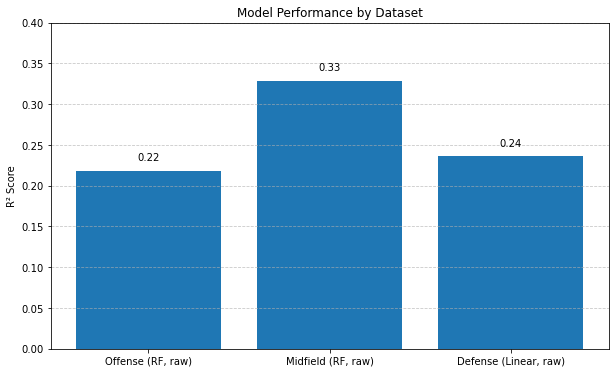

In [ ]:
'''
# Example final R² values
final_r2_scores = {
    "Offense (RF, raw)": 0.218,
    "Midfield (RF, raw)": 0.329,
    "Defense (Linear, raw)": 0.236
}

import matplotlib.pyplot as plt

# Extract labels and values
labels = list(final_r2_scores.keys())
values = list(final_r2_scores.values())

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, values)
plt.ylabel("R² Score")
plt.title("Model Performance by Dataset")
plt.ylim(0, 0.4)  # Set y-axis limit a bit higher than highest R²
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')

plt.show()
'''
def clean_columns(df):
    """Fix messy column names."""
    rename_map = {}
    if "Value.x" in df.columns:
        rename_map["Value.x"] = "Value"
    if "Position.x" in df.columns:
        rename_map["Position.x"] = "Position"
    if "Age.x.x" in df.columns:
        rename_map["Age.x.x"] = "Age"
    if "Age.x" in df.columns and "Age" not in df.columns:
        rename_map["Age.x"] = "Age"

    df = df.rename(columns=rename_map)
    return df



In [ ]:
!pip install gradio

     |████████████████████████████████| 18.1 MB 9.1 MB/s eta 0:00:01
     |████████████████████████████████| 62 kB 7.5 MB/s  eta 0:00:01
     |████████████████████████████████| 318 kB 20.0 MB/s eta 0:00:01
     |████████████████████████████████| 128 kB 20.8 MB/s eta 0:00:01
     |████████████████████████████████| 73 kB 11.3 MB/s eta 0:00:01
     |████████████████████████████████| 481 kB 27.9 MB/s eta 0:00:01
     |████████████████████████████████| 45 kB 8.6 MB/s  eta 0:00:01
     |████████████████████████████████| 443 kB 15.1 MB/s eta 0:00:01
     |████████████████████████████████| 95 kB 13.0 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 11.0 MB 16.6 MB/s eta 0:00:01
     |████████████████████████████████| 121 kB 11.2 MB/s eta 0:00:01
     |████████████████████████████████| 72 kB 2.7 MB/s  eta 0:00:01
     |████████████████████████████████| 78 kB 13.4 MB/s eta 0:00:01
     |████████████████████████████████| 

     |████████████████████████████████| 64 kB 11.0 MB/s eta 0:00:01
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.9
    Uninstalling urllib3-1.26.9:
      Successfully uninstalled urllib3-1.26.9
  Attempting uninstall: h11
    Found existing installation: h11 0.14.0
    Uninstalling h11-0.14.0:
      Successfully uninstalled h11-0.14.0
  Attempting uninstall: requests
    Found existing installation: requests 2.27.1
    Uninstalling requests-2.27.1:
      Successfully uninstalled requests-2.27.1
  Attempting uninstall: pygments
    Found existing installation: Pygments 2.11.2
    Uninstalling Pygments-2.11.2:
      Successfully uninstalled Pygments-2.11.2
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2022.2.0
    Uninstalling fsspec-2022.2.0:
      Successfully uninstalled fsspec-2022.2.0
  Attempting uninstall: anyio
    Found existing installation: anyio 3.5.0
    Uninstalling anyio-3.5.0:
      Successfully uninstalled anyio-3

In [ ]:
import gradio as gr
import pandas as pd

# Define your prediction function
def predict_value(GA, expected_contribution, shots, position, age_group):
    input_data = pd.DataFrame({
        "G+A": [GA],
        "Expected_Contribution": [expected_contribution],
        "Sh_Standard": [shots],
        "Position": [position],
        "Age_Group": [age_group]
    })
    prediction = pipeline.predict(input_data)[0]
    return f"Estimated Market Value: €{prediction:,.0f}"

# Create the Gradio interface
demo = gr.Interface(
    fn=predict_value,
    inputs=[
        gr.Number(label="Goals + Assists (G+A)"),
        gr.Number(label="Expected Contribution (xG + xAG)"),
        gr.Number(label="Total Shots"),
        gr.Dropdown(choices=["FW", "MF", "DF"], label="Position"),
        gr.Dropdown(choices=["Young", "Prime", "Veteran"], label="Age Group"),
    ],
    outputs="text",
    title="⚽ Soccer Transfer Market Value Predictor"
)

# Launch the app
demo.launch()

TypeError: __init__() got an unexpected keyword argument 'dynamic_inputs'